## Análise Reutilizável com Função

Para facilitar a análise de múltiplos DataFrames, vou definir uma função que encapsula todas as etapas de inspeção e visualização realizadas anteriormente.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def analyze_dataframe(df, df_name):
    print(f"\n{'='*60}\nIniciando Análise para o DataFrame: {df_name}\n{'='*60}")

    # 1. Shape e dtypes
    print(f"\nShape da tabela de {df_name}: {df.shape}")
    print(f"Colunas da tabela de {df_name} e seus tipos:\n {df.dtypes}")

    # 2. Checando ocorrências de 'NULL'/'null' em colunas object
    print(f"\nVerificando 'NULL'/'null' strings em colunas de texto para {df_name}:")
    object_cols = df.select_dtypes(include='object').columns
    for col in object_cols:
        count_null_strings = df[col].isin(['NULL', 'null']).sum()
        print(f"Ocorrências da string 'NULL'/'null' em {col} (no {df_name}): {count_null_strings}")

    # 3. Nulos por coluna
    print(f"\nNúmero de nulos por coluna no {df_name}:\n {df.isnull().sum()}")

    # 4. Registros duplicados
    print(f"\nNúmero de registros duplicados na tabela de {df_name}: {df.duplicated().sum()}")

    # 5. Análise de Datas (Inicio e Fim)
    if 'Inicio' in df.columns and pd.api.types.is_datetime64_any_dtype(df['Inicio']):
        print(f"\nLimite inferior das datas de Inicio no {df_name}: {df['Inicio'].min()}")
        print(f"Limite superior das datas de Inicio no {df_name}: {df['Inicio'].max()}")

        # 6. Janela de tempo e média de apontamentos
        time_window = df['Inicio'].max() - df['Inicio'].min()
        print(f"Janela de tempo no {df_name}: {time_window}")

        time_window_days = time_window.days + (1 if time_window.seconds > 0 else 0)
        if time_window_days == 0:
            time_window_days = 1
        print(f"Média de apontamentos por dia no {df_name}: {round(df.shape[0] / time_window_days, 2)}")

        time_window_hours = time_window_days * 24
        print(f"Média de apontamentos por hora no {df_name}: {round(df.shape[0] / time_window_hours, 2)}")
    else:
        print(f"\nO DataFrame {df_name} não possui uma coluna 'Inicio' ou ela não é do tipo datetime. Pulando análises de tempo.")

    # 7. Média de registros por equipamento (se 'Tag' existe)
    if 'Tag' in df.columns:
        registros_por_tag = df.groupby('Tag').size()
        media_registros_por_equipamento = registros_por_tag.mean()
        print(f"\nMédia de registros por equipamento no {df_name}: {media_registros_por_equipamento:.2f}")
    else:
        print(f"\nO DataFrame {df_name} não possui uma coluna 'Tag'. Pulando média de registros por equipamento.")

    # 8. Distribuição temporal dos registros
    if 'Inicio' in df.columns and pd.api.types.is_datetime64_any_dtype(df['Inicio']):
        print(f"\n### Distribuição Temporal dos Registros para {df_name}")

        # Create copies of the dataframe for plotting to avoid SettingWithCopyWarning
        df_plot = df.copy()
        df_plot['Dia'] = df_plot['Inicio'].dt.date
        df_plot['Hora'] = df_plot['Inicio'].dt.hour

        distribuicao_diaria = df_plot.groupby('Dia').size().reset_index(name='Volume')
        distribuicao_horaria = df_plot.groupby('Hora').size().reset_index(name='Volume')

        plt.figure(figsize=(15, 6))
        sns.lineplot(x='Dia', y='Volume', data=distribuicao_diaria)
        plt.title(f'Volume de Registros de Apontamentos por Dia - {df_name}')
        plt.xlabel('Dia')
        plt.ylabel('Volume de Registros')
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(15, 6))
        sns.lineplot(x='Hora', y='Volume', data=distribuicao_horaria)
        plt.title(f'Volume de Registros de Apontamentos por Hora do Dia - {df_name}')
        plt.xlabel('Hora do Dia')
        plt.ylabel('Volume de Registros')
        plt.xticks(range(0, 24))
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    else:
        print(f"\nO DataFrame {df_name} não possui uma coluna 'Inicio' ou ela não é do tipo datetime. Pulando plots de distribuição temporal.")



## Executando a Análise para `df_ap` (Parquet)


Iniciando Análise para o DataFrame: df_ap_parquet

Shape da tabela de df_ap_parquet: (377907, 7)
Colunas da tabela de df_ap_parquet e seus tipos:
 Id                 int64
Inicio    datetime64[ns]
Fim       datetime64[ns]
Tag               object
Frota             object
Tipo              object
Classe            object
dtype: object

Verificando 'NULL'/'null' strings em colunas de texto para df_ap_parquet:
Ocorrências da string 'NULL'/'null' em Tag (no df_ap_parquet): 0
Ocorrências da string 'NULL'/'null' em Frota (no df_ap_parquet): 0
Ocorrências da string 'NULL'/'null' em Tipo (no df_ap_parquet): 0
Ocorrências da string 'NULL'/'null' em Classe (no df_ap_parquet): 0

Número de nulos por coluna no df_ap_parquet:
 Id        0
Inicio    0
Fim       0
Tag       0
Frota     0
Tipo      0
Classe    0
dtype: int64

Número de registros duplicados na tabela de df_ap_parquet: 0

Limite inferior das datas de Inicio no df_ap_parquet: 2025-01-01 00:00:00
Limite superior das datas de Inicio no df

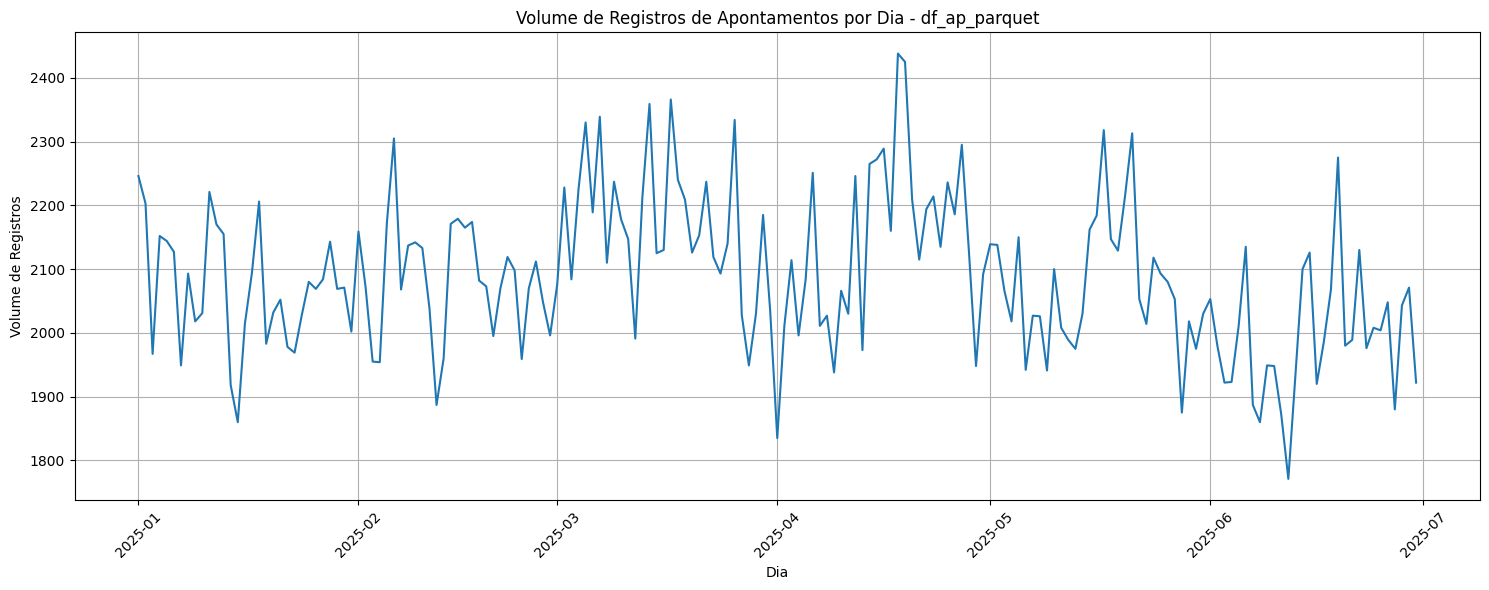

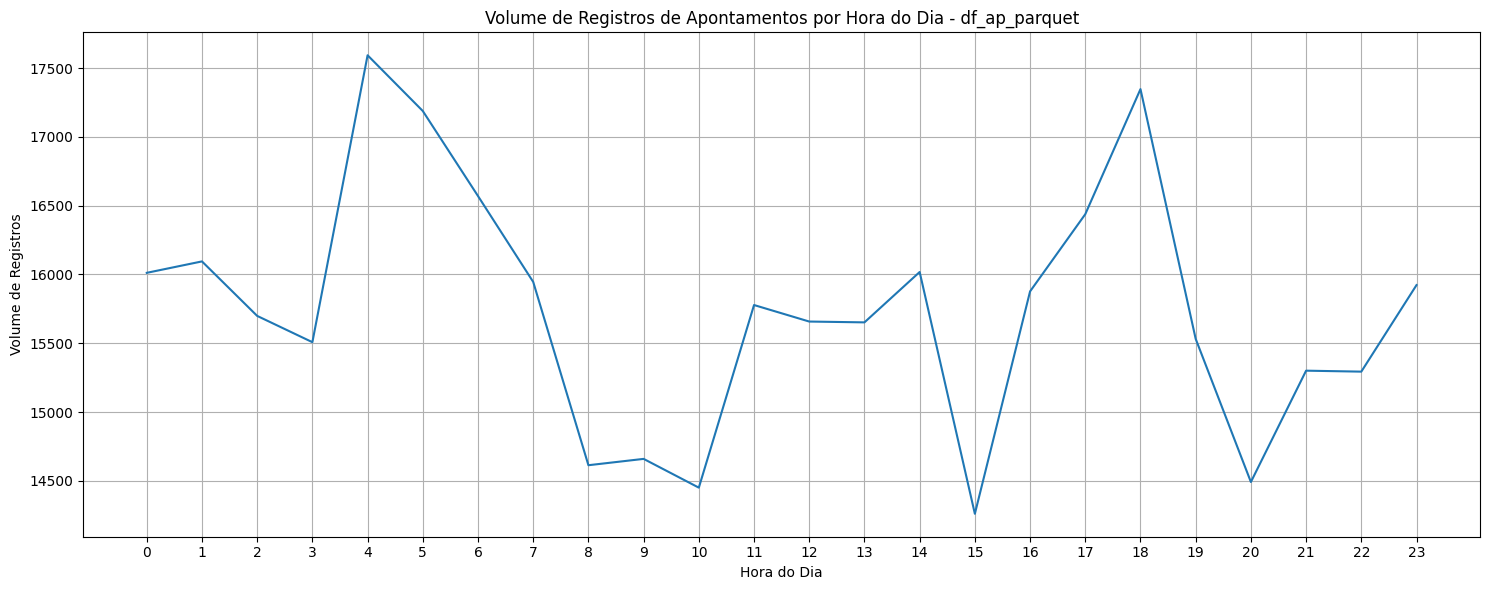

In [ ]:
parquet_file_path = 'drive/MyDrive/hackathon-vale/apontamentos/desenvolver_apontamentos.parquet'
df_ap = pd.read_parquet(parquet_file_path)


analyze_dataframe(df_ap.copy(), 'df_ap_parquet')

## Executando a Análise para `desenvolver_apontamentos.xlsx`


Iniciando Análise para o DataFrame: df_ap_excel

Shape da tabela de df_ap_excel: (100, 7)
Colunas da tabela de df_ap_excel e seus tipos:
 Id                 int64
Inicio    datetime64[ns]
Fim       datetime64[ns]
Tag               object
Frota             object
Tipo              object
Classe            object
dtype: object

Verificando 'NULL'/'null' strings em colunas de texto para df_ap_excel:
Ocorrências da string 'NULL'/'null' em Tag (no df_ap_excel): 0
Ocorrências da string 'NULL'/'null' em Frota (no df_ap_excel): 0
Ocorrências da string 'NULL'/'null' em Tipo (no df_ap_excel): 0
Ocorrências da string 'NULL'/'null' em Classe (no df_ap_excel): 0

Número de nulos por coluna no df_ap_excel:
 Id        0
Inicio    0
Fim       0
Tag       0
Frota     0
Tipo      0
Classe    0
dtype: int64

Número de registros duplicados na tabela de df_ap_excel: 0

Limite inferior das datas de Inicio no df_ap_excel: 2025-01-04 19:12:28
Limite superior das datas de Inicio no df_ap_excel: 2025-01-08 02:

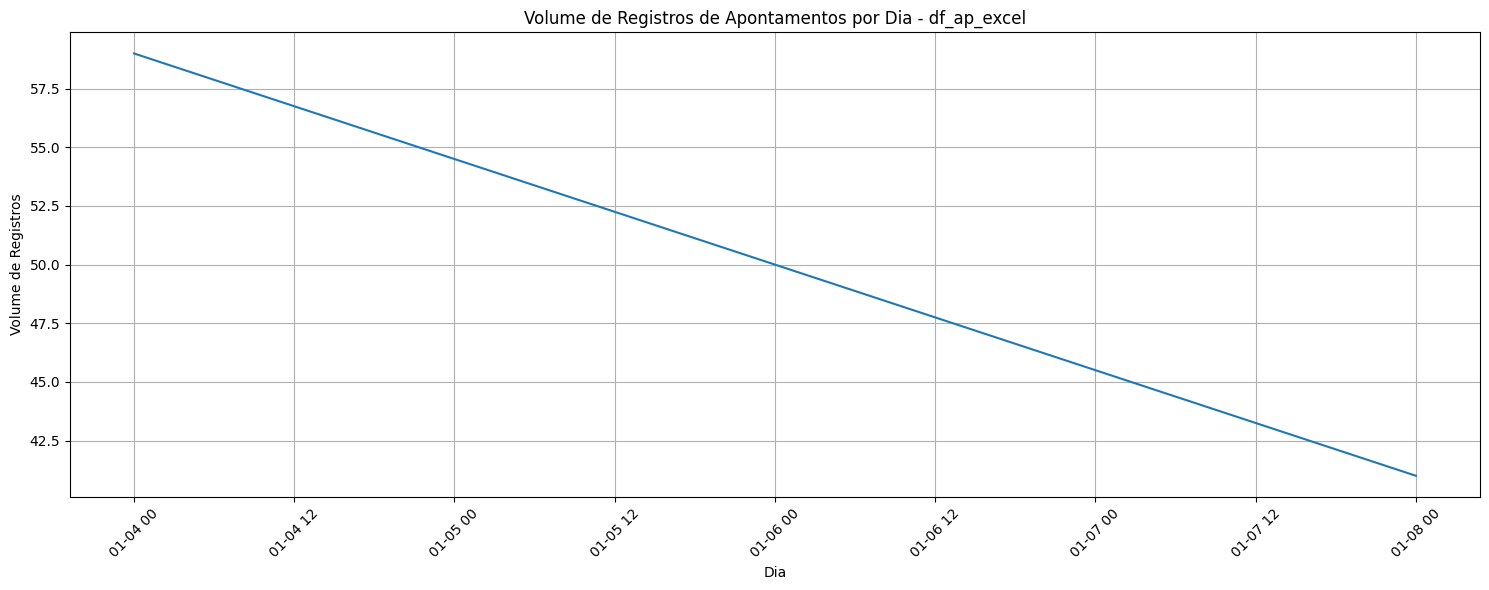

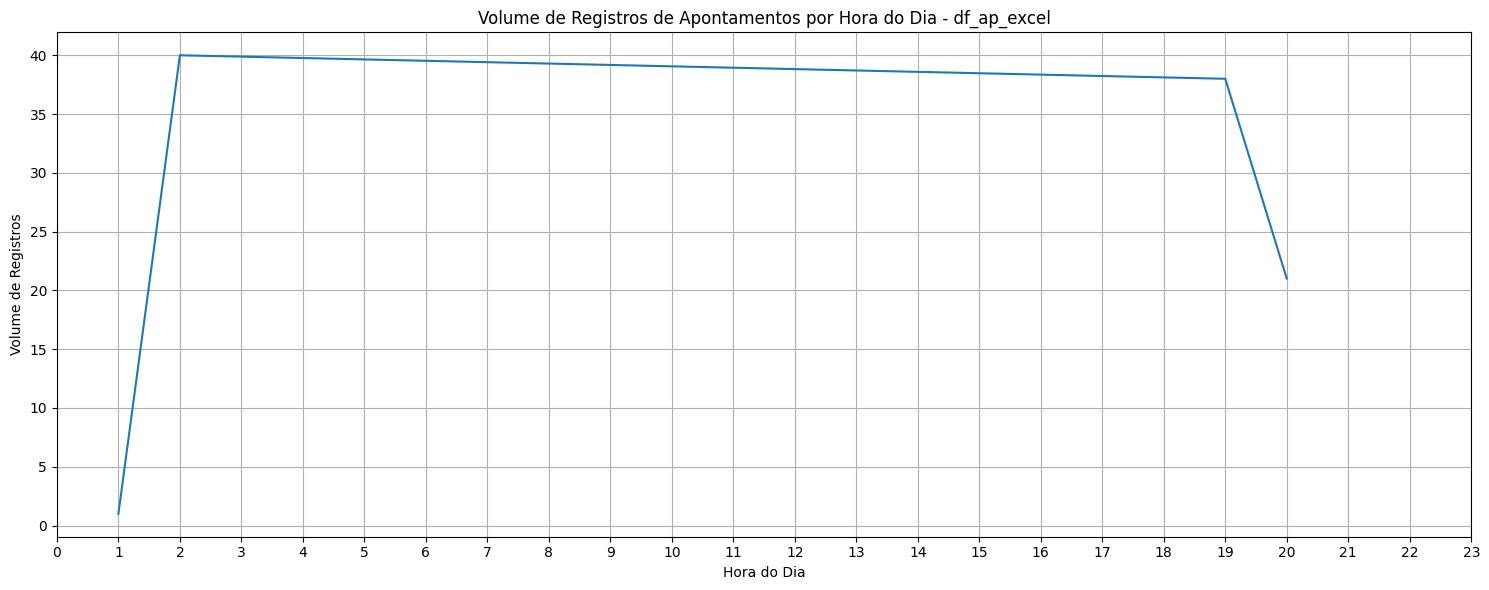

In [ ]:
excel_file_path = 'drive/MyDrive/hackathon-vale/apontamentos/desenvolver_apontamentos.xlsx'
df_ap_excel_new = pd.read_excel(excel_file_path)

analyze_dataframe(df_ap_excel_new.copy(), 'df_ap_excel')